In [1]:
from pathlib import Path
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"

SPLITS = ["training", "validation", "evaluation"]

train_dir = DATA_DIR / "training"

classes = sorted([
    folder.name
    for folder in train_dir.iterdir()
    if folder.is_dir()
])

print("Putanja do dataseta:", DATA_DIR.resolve())
print("Broj klasa:", len(classes))
print("Klase:")
for cls in classes:
    print("-", cls)

Putanja do dataseta: D:\Vestacka Inteligencija Master\Food11-Classification\data
Broj klasa: 11
Klase:
- Bread
- Dairy product
- Dessert
- Egg
- Fried food
- Meat
- Noodles-Pasta
- Rice
- Seafood
- Soup
- Vegetable-Fruit


In [3]:
import pandas as pd

records = []

for split in SPLITS:
    split_dir = DATA_DIR / split

    for cls in classes:
        class_dir = split_dir / cls

        image_files = [
            f for f in class_dir.iterdir()
            if f.is_file()
        ]

        records.append({
            "split": split,
            "class": cls,
            "image_count": len(image_files)
        })

df_counts = pd.DataFrame(records)

df_counts

ModuleNotFoundError: No module named 'pandas'

In [5]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

In [7]:
import pandas as pd

records = []

for split in SPLITS:
    split_dir = DATA_DIR / split

    for cls in classes:
        class_dir = split_dir / cls

        image_files = [
            f for f in class_dir.iterdir()
            if f.is_file()
        ]

        records.append({
            "split": split,
            "class": cls,
            "image_count": len(image_files)
        })

df_counts = pd.DataFrame(records)

df_counts

,split,class,image_count
0,training,Bread,994
1,training,Dairy product,429
2,training,Dessert,1500
3,training,Egg,986
4,training,Fried food,848
5,training,Meat,1325
6,training,Noodles-Pasta,440
7,training,Rice,280
8,training,Seafood,855
9,training,Soup,1500


In [8]:
print("Ukupan broj slika po splitu:")
display(
    df_counts.groupby("split")["image_count"]
    .sum()
    .to_frame()
)

print("\nDeskriptivna statistika broja slika po klasama:")
display(
    df_counts.groupby("split")["image_count"]
    .describe()
)

Ukupan broj slika po splitu:


,image_count
split,
evaluation,3347
training,9866
validation,3430



Deskriptivna statistika broja slika po klasama:


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
evaluation,11.0,304.272727,140.050056,96.0,189.5,303.0,400.0,500.0
training,11.0,896.909091,421.402766,280.0,574.5,855.0,1159.5,1500.0
validation,11.0,311.818182,142.164565,96.0,189.5,327.0,405.5,500.0


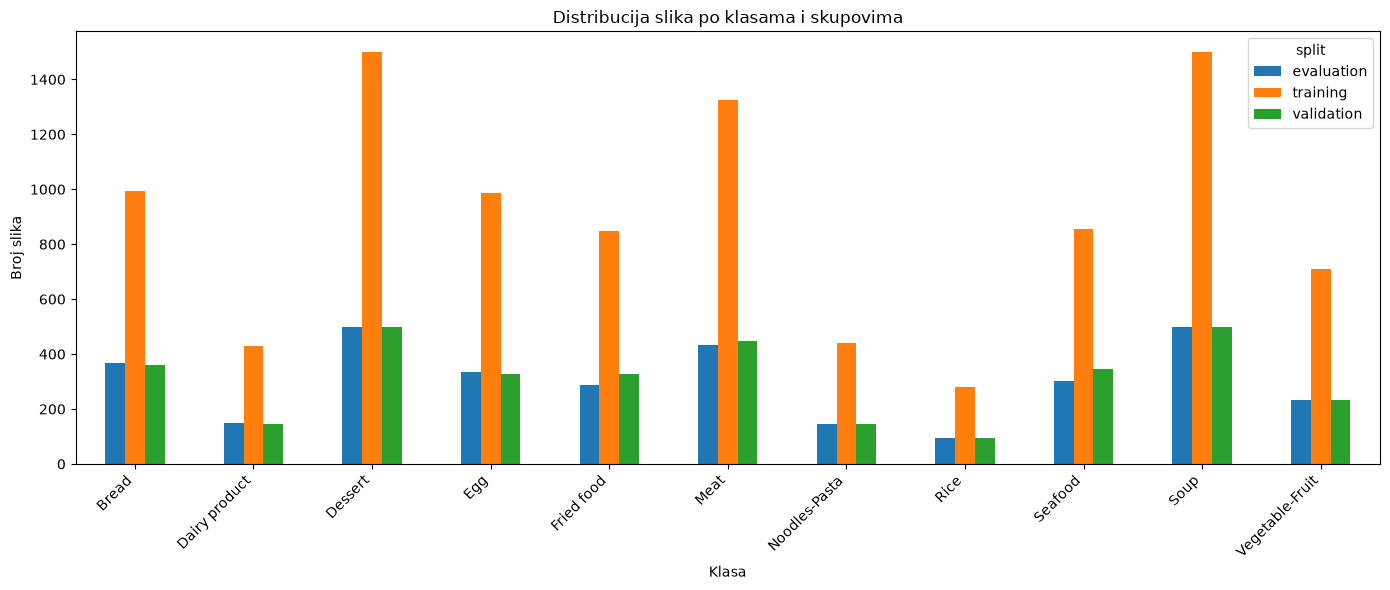

In [9]:
pivot_counts = df_counts.pivot(
    index="class",
    columns="split",
    values="image_count"
)

pivot_counts.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Distribucija slika po klasama i skupovima")
plt.xlabel("Klasa")
plt.ylabel("Broj slika")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
for split in SPLITS:
    split_data = df_counts[df_counts["split"] == split]

    min_count = split_data["image_count"].min()
    max_count = split_data["image_count"].max()
    mean_count = split_data["image_count"].mean()

    print(f"{split}:")
    print(f"  Minimum slika u klasi: {min_count}")
    print(f"  Maksimum slika u klasi: {max_count}")
    print(f"  Prosek slika po klasi: {mean_count:.2f}")
    print(f"  Odnos max/min: {max_count / min_count:.2f}")
    print()

training:
  Minimum slika u klasi: 280
  Maksimum slika u klasi: 1500
  Prosek slika po klasi: 896.91
  Odnos max/min: 5.36

validation:
  Minimum slika u klasi: 96
  Maksimum slika u klasi: 500
  Prosek slika po klasi: 311.82
  Odnos max/min: 5.21

evaluation:
  Minimum slika u klasi: 96
  Maksimum slika u klasi: 500
  Prosek slika po klasi: 304.27
  Odnos max/min: 5.21



In [11]:
corrupted_images = []

for split in SPLITS:
    split_dir = DATA_DIR / split

    for cls in classes:
        class_dir = split_dir / cls

        for image_path in class_dir.iterdir():
            if not image_path.is_file():
                continue

            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception:
                corrupted_images.append(str(image_path))

print("Broj oštećenih/nečitljivih slika:", len(corrupted_images))

if corrupted_images:
    print("\nPrimeri problematičnih fajlova:")
    for path in corrupted_images[:20]:
        print(path)
else:
    print("Nisu pronađene oštećene slike.")

Broj oštećenih/nečitljivih slika: 0
Nisu pronađene oštećene slike.


In [12]:
image_sizes = []

MAX_IMAGES_TO_CHECK = 1000
checked = 0

for split in SPLITS:
    for cls in classes:
        class_dir = DATA_DIR / split / cls

        for image_path in class_dir.iterdir():
            if not image_path.is_file():
                continue

            try:
                with Image.open(image_path) as img:
                    width, height = img.size

                image_sizes.append({
                    "split": split,
                    "class": cls,
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height
                })

                checked += 1

                if checked >= MAX_IMAGES_TO_CHECK:
                    break

            except Exception:
                pass

        if checked >= MAX_IMAGES_TO_CHECK:
            break

    if checked >= MAX_IMAGES_TO_CHECK:
        break

df_sizes = pd.DataFrame(image_sizes)

print("Broj analiziranih slika:", len(df_sizes))
display(df_sizes[["width", "height", "aspect_ratio"]].describe())

Broj analiziranih slika: 1000


,width,height,aspect_ratio
count,1000.000000,1000.00000,1000.000000
mean,498.246000,471.61000,1.087739
std,45.200449,68.04375,0.234963
min,306.000000,259.00000,0.597656
25%,512.000000,384.00000,1.000000
50%,512.000000,512.00000,1.000000
75%,512.000000,512.00000,1.333333
max,960.000000,540.00000,1.976834


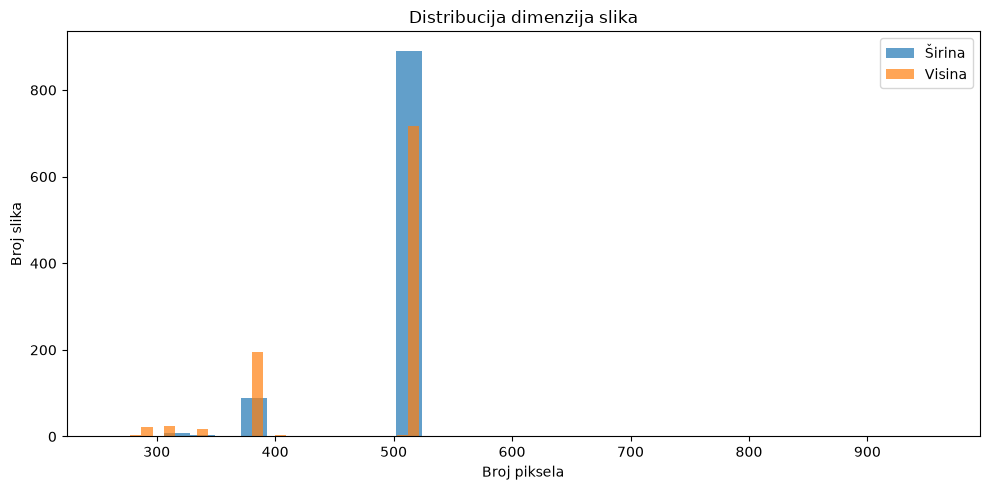

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(df_sizes["width"], bins=30, alpha=0.7, label="Širina")
plt.hist(df_sizes["height"], bins=30, alpha=0.7, label="Visina")

plt.title("Distribucija dimenzija slika")
plt.xlabel("Broj piksela")
plt.ylabel("Broj slika")
plt.legend()
plt.tight_layout()
plt.show()

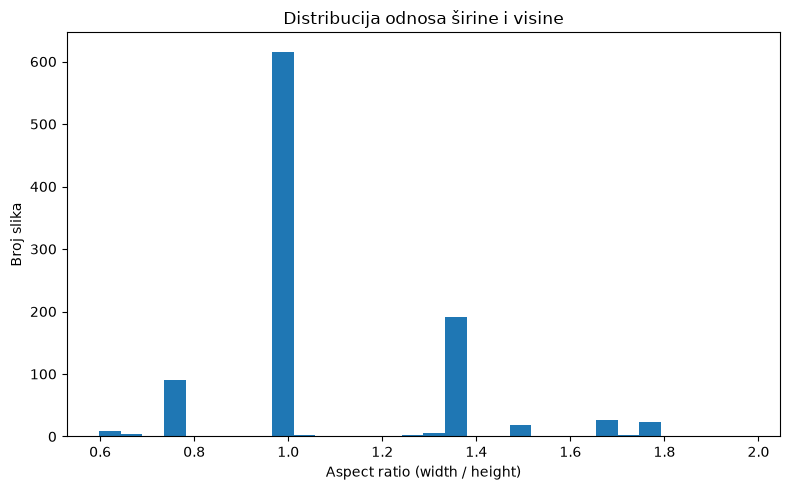

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(df_sizes["aspect_ratio"], bins=30)

plt.title("Distribucija odnosa širine i visine")
plt.xlabel("Aspect ratio (width / height)")
plt.ylabel("Broj slika")
plt.tight_layout()
plt.show()

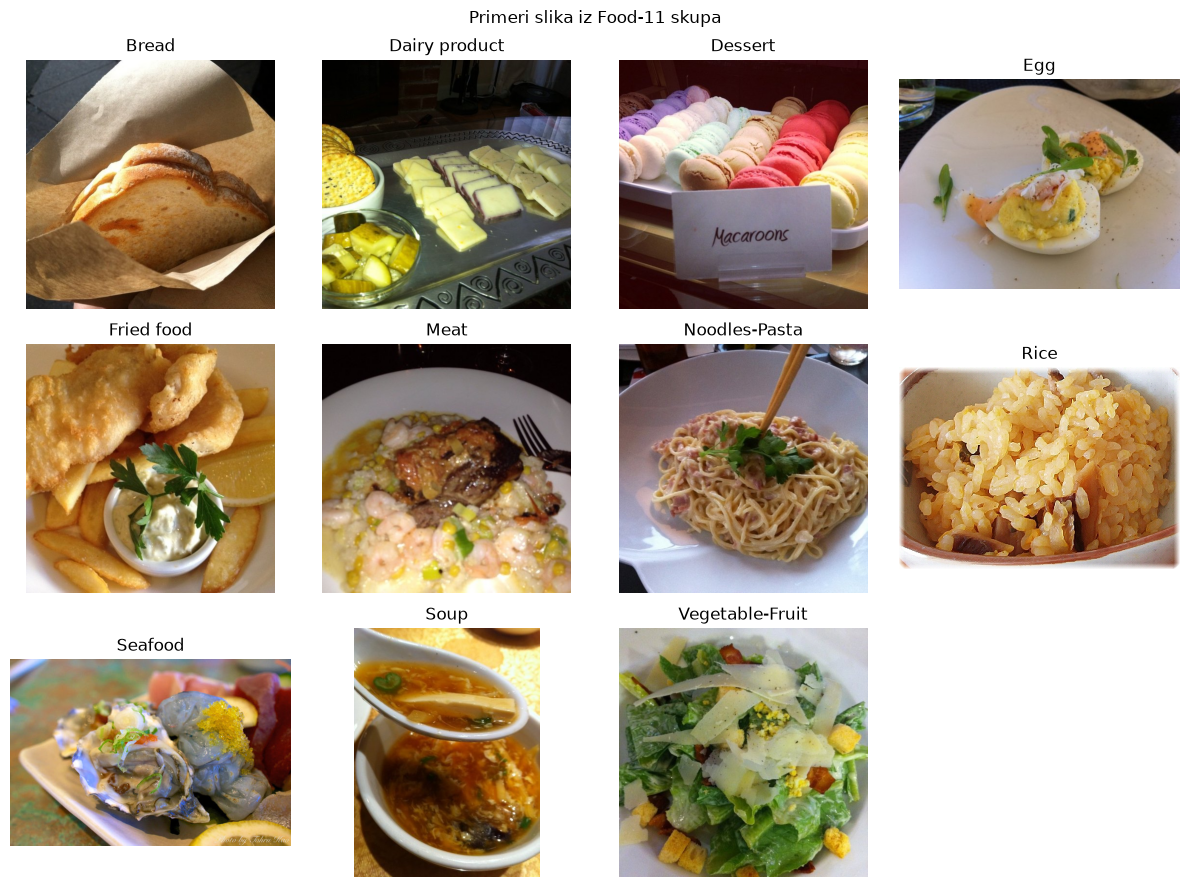

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for i, cls in enumerate(classes[:11]):
    class_dir = DATA_DIR / "training" / cls

    image_files = [
        f for f in class_dir.iterdir()
        if f.is_file()
    ]

    sample_path = random.choice(image_files)

    with Image.open(sample_path) as img:
        axes[i].imshow(img.convert("RGB"))

    axes[i].set_title(cls)
    axes[i].axis("off")

axes[-1].axis("off")

plt.suptitle("Primeri slika iz Food-11 skupa")
plt.tight_layout()
plt.show()

## Provera nedostajućih podataka i korelacija

Food-11 je skup podataka organizovan kao kolekcija slika raspoređenih po klasama i podelama
(training, validation i evaluation), a ne kao tabelarni skup podataka sa numeričkim kolonama.

Zbog toga klasična analiza nedostajućih vrednosti (`NaN`, `None`) nije direktno primenljiva.
Umesto toga provereno je:

- da li postoje sve očekivane klase u svim podelama skupa,
- da li postoje prazni direktorijumi klasa,
- da li postoje oštećene ili nečitljive slike,
- broj slika po klasi i podeli.

Klasična korelaciona matrica između atributa takođe nije direktno primenljiva na sirove slike,
jer svaka slika predstavlja višedimenzionalni skup piksela, a ne skup unapred definisanih
numeričkih karakteristika.

Kao relevantne deskriptivne karakteristike analizirane su dimenzije slika
(širina, visina i odnos širine i visine), kao i distribucija broja uzoraka po klasama.

## Zaključak analize skupa podataka

Analizom je proverena struktura Food-11 skupa, broj uzoraka po klasama,
ispravnost fajlova i osnovne karakteristike dimenzija slika.

Dobijeni rezultati predstavljaju osnovu za definisanje reproducibilnog preprocessing
pipeline-a koji će se koristiti tokom treniranja i evaluacije neuronskih mreža.